# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Franco Marcelo Morero

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 7 de agosto (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dLacTc6eZMWjWGZJA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP2-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP2-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

### Carga de datos e inspección inicial

Arranco cargando los dos archivos ya separados (adult_train.csv y adult_val.csv) y mirando forma, tipos y primeras filas. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
train = pd.read_csv("adult_train.csv")
val = pd.read_csv("adult_val.csv")

print(f"train: {train.shape}")
print(f"val:   {val.shape}")

train: (30162, 14)
val:   (15060, 14)


In [3]:
train.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB


In [5]:
nulos = pd.DataFrame({
    "n_nulos": train.isna().sum(),
    "pct_nulos": (train.isna().mean() * 100).round(2),
})
print(nulos.sort_values("n_nulos", ascending=False))

                n_nulos  pct_nulos
age                   0        0.0
workclass             0        0.0
education             0        0.0
marital-status        0        0.0
occupation            0        0.0
relationship          0        0.0
race                  0        0.0
sex                   0        0.0
capital-gain          0        0.0
capital-loss          0        0.0
hours-per-week        0        0.0
skill-profile         0        0.0
native-country        0        0.0
income                0        0.0


In [6]:
nulos_val = pd.DataFrame({
    "n_nulos": val.isna().sum(),
    "pct_nulos": (val.isna().mean() * 100).round(2),
})
print(nulos_val.sort_values("n_nulos", ascending=False))

                n_nulos  pct_nulos
age                   0        0.0
workclass             0        0.0
education             0        0.0
marital-status        0        0.0
occupation            0        0.0
relationship          0        0.0
race                  0        0.0
sex                   0        0.0
capital-gain          0        0.0
capital-loss          0        0.0
hours-per-week        0        0.0
skill-profile         0        0.0
native-country        0        0.0
income                0        0.0


In [7]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,30162.0,NaN,NaN,NaN,38.437902,13.134665,17.0,28.0,37.0,47.0,90.0
workclass,30162,7,Private,22286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,30162,16,HS-grad,9840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital-status,30162,7,Married-civ-spouse,14065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,30162,14,Prof-specialty,4038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,30162,6,Husband,12463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,30162,5,White,25933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,30162,2,Male,20380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,30162.0,NaN,NaN,NaN,1092.007858,7406.346497,0.0,0.0,0.0,0.0,99999.0
capital-loss,30162.0,NaN,NaN,NaN,88.372489,404.29837,0.0,0.0,0.0,0.0,4356.0


In [8]:
train.nunique().sort_values()

sex                 2
income              2
race                5
relationship        6
workclass           7
marital-status      7
occupation         14
education          16
native-country     41
age                72
skill-profile      80
capital-loss       90
hours-per-week     94
capital-gain      118
dtype: int64

In [9]:
val.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,15060.0,NaN,NaN,NaN,38.768327,13.380676,17.0,28.0,37.0,48.0,90.0
workclass,15060,7,Private,11021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,15060,16,HS-grad,4943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital-status,15060,7,Married-civ-spouse,6990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,15060,14,Exec-managerial,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,15060,6,Husband,6203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,15060,5,White,12970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,15060,2,Male,10147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,15060.0,NaN,NaN,NaN,1120.301594,7703.181842,0.0,0.0,0.0,0.0,99999.0
capital-loss,15060.0,NaN,NaN,NaN,89.041899,406.283245,0.0,0.0,0.0,0.0,3770.0


In [10]:
val.nunique().sort_values()

sex                 2
income              2
race                5
relationship        6
workclass           7
marital-status      7
occupation         14
education          16
native-country     40
age                73
capital-loss       79
skill-profile      80
hours-per-week     89
capital-gain      110
dtype: int64

In [11]:
print("duplicados train:", train.duplicated().sum())
print("duplicados val:  ", val.duplicated().sum())

duplicados train: 479
duplicados val:   118


In [12]:
# consistencia de categorias entre train y val, 
# para que no nos falten al crear el vocabulario de los embeddings
cat_cols = [c for c in train.select_dtypes("object").columns if c != "income"]
print("\ncategorias presentes en val y ausentes en train:")
hay = False
for c in cat_cols:
    faltan = set(val[c].unique()) - set(train[c].unique())
    if faltan:
        hay = True
        print(f"  {c}: {faltan}")
if not hay:
    print("  ninguna (val no aporta categorias nuevas)")


categorias presentes en val y ausentes en train:
  ninguna (val no aporta categorias nuevas)


Observaciones iniciales

El dataset tiene 14 columnas y ninguna fila con nulos. Hay algunos pocos duplicados. 

Agrupo las variables por lo que representan:

- **Demográficas:** age, sex, race, native-country, marital-status, relationship.
- **Laborales / educativas:** workclass, occupation, education, skill-profile, hours-per-week.
- **Financieras:** capital-gain, capital-loss.
- **Objetivo:** income (binaria, <=50K / >50K).

Cuatro columnas son numéricas enteras (age, capital-gain, capital-loss, hours-per-week) y el resto son categóricas de tipo texto. 

Se puede ve que la cardinalidad varía mucho entre categóricas, teniendo desde sex con 2 valores hasta skill-profile con 80. 

El dataset de de validación no contiene ninguna categoría que no esté en entrenamiento. Es bueno porque cualquier vocabulario para embeddings que arme sobre train cubre a las categorias en validación.

### Variable objetivo income

Miro la distribución de la clase en train y val. 

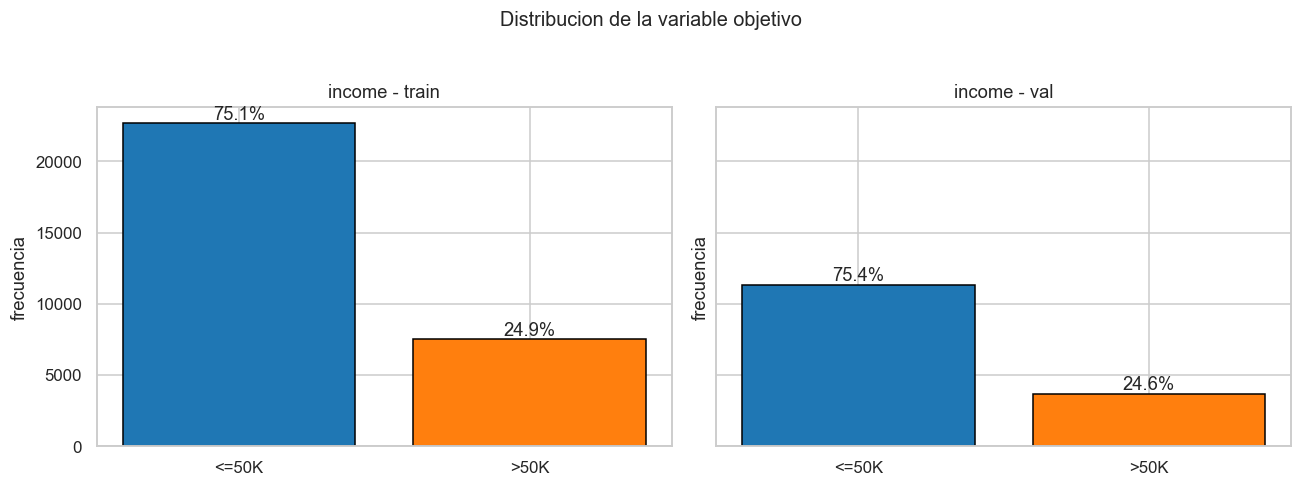

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (nombre, d) in zip(axes, [("train", train), ("val", val)]):
    vc = d["income"].value_counts()
    pct = d["income"].value_counts(normalize=True) * 100
    bars = ax.bar(vc.index, vc.values, color=["tab:blue", "tab:orange"], edgecolor="black")
    for b, p in zip(bars, pct):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{p:.1f}%", ha="center", va="bottom")
    ax.set_title(f"income - {nombre}")
    ax.set_ylabel("frecuencia")
fig.suptitle("Distribucion de la variable objetivo", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

La clase está desbalanceada, alrededor del 75% de las personas gana <=50K y solo un 25% gana >50K. La proporción es prácticamente igual en train y en val, así que la partición de los datos es correcta.

### Variables numéricas

In [14]:
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]

stats = pd.DataFrame({
    "media": train[num_cols].mean(),
    "mediana": train[num_cols].median(),
    "moda": [train[c].mode().iloc[0] for c in num_cols],
    "std": train[num_cols].std(),
    "min": train[num_cols].min(),
    "max": train[num_cols].max(),
}).round(2)
stats

,media,mediana,moda,std,min,max
age,38.44,37.0,36,13.13,17,90
capital-gain,1092.01,0.0,0,7406.35,0,99999
capital-loss,88.37,0.0,0,404.30,0,4356
hours-per-week,40.93,40.0,40,11.98,1,99


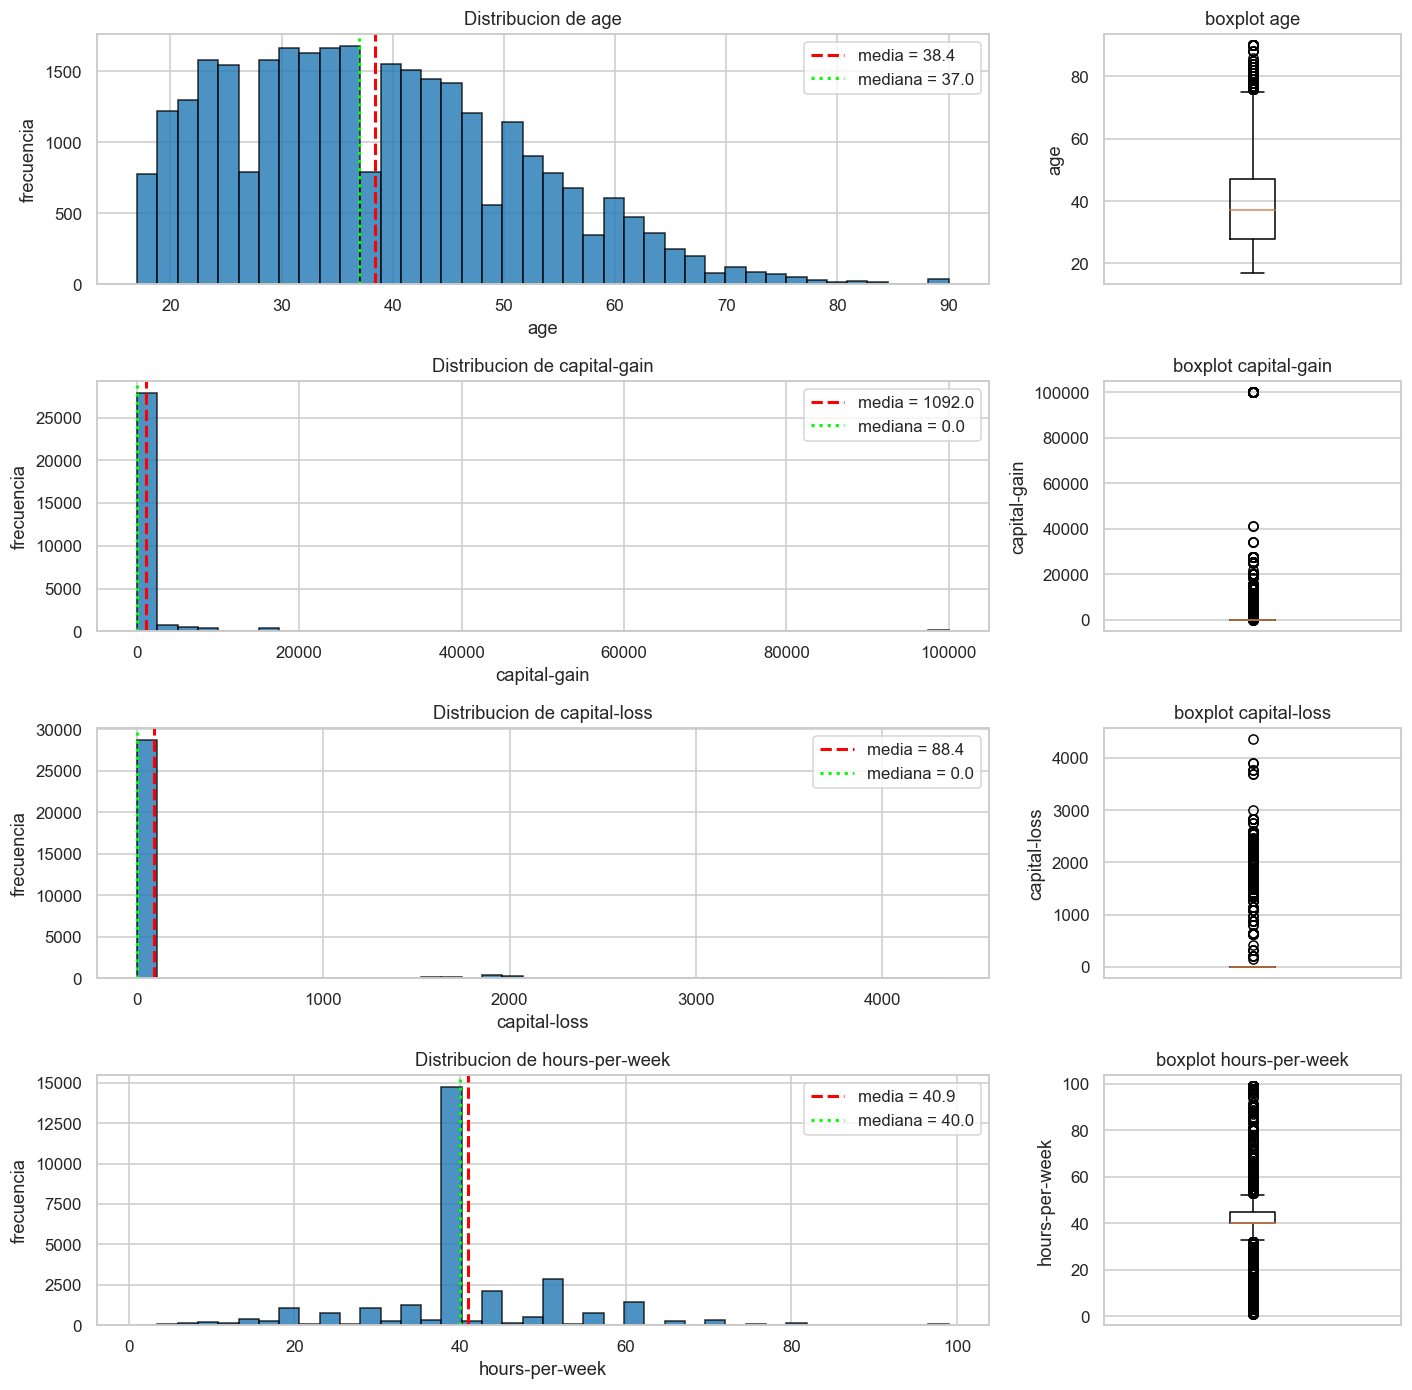

In [15]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(13, 3.2 * len(num_cols)),
                         gridspec_kw={"width_ratios": [3, 1]})
for (ax_h, ax_b), col in zip(axes, num_cols):
    s = train[col]
    ax_h.hist(s, bins=40, color="tab:blue", edgecolor="black", alpha=0.8)
    ax_h.axvline(s.mean(), color="red", ls="--", lw=2, label=f"media = {s.mean():.1f}")
    ax_h.axvline(s.median(), color="lime", ls=":", lw=2, label=f"mediana = {s.median():.1f}")
    ax_h.set_title(f"Distribucion de {col}")
    ax_h.set_xlabel(col); ax_h.set_ylabel("frecuencia"); ax_h.legend()
    ax_b.boxplot(s, vert=True)
    ax_b.set_title(f"boxplot {col}")
    ax_b.set_ylabel(col)
    ax_b.set_xticks([])
plt.tight_layout()
plt.show()

capital-gain y capital-loss estan dominadas por ceros, miro cuanto pesan

In [16]:
for col in ["capital-gain", "capital-loss"]:
    pct_cero = (train[col] == 0).mean() * 100
    sub = train.loc[train[col] > 0, col]
    print(f"{col}: {pct_cero:.1f}% en cero | no-cero -> n={len(sub)}, "
          f"mediana={sub.median():.0f}, max={sub.max()}")

capital-gain: 91.6% en cero | no-cero -> n=2538, mediana=7298, max=99999
capital-loss: 95.3% en cero | no-cero -> n=1427, mediana=1887, max=4356


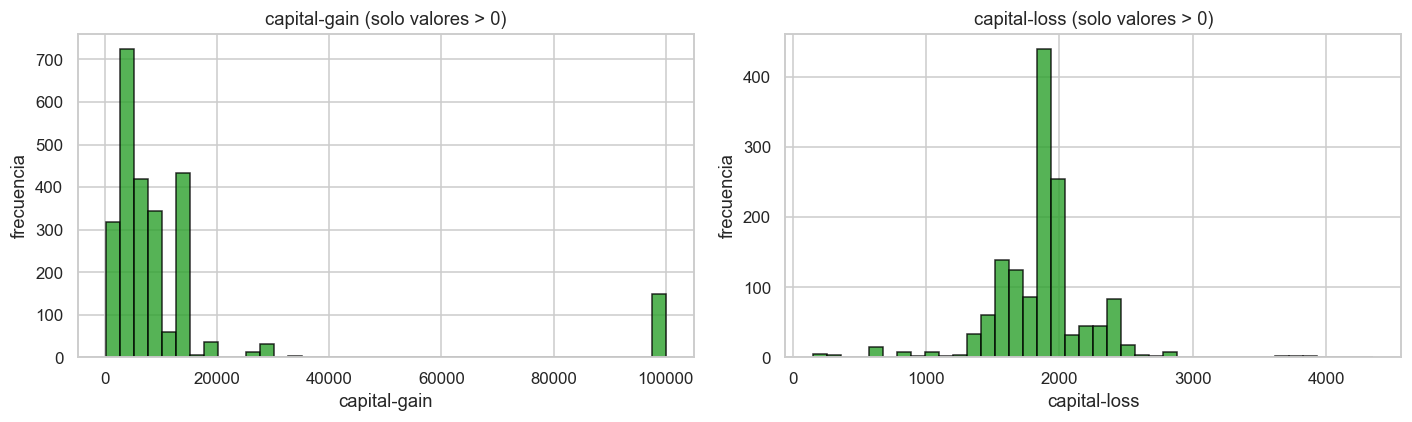

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["capital-gain", "capital-loss"]):
    sub = train.loc[train[col] > 0, col]
    ax.hist(sub, bins=40, color="tab:green", edgecolor="black", alpha=0.8)
    ax.set_title(f"{col} (solo valores > 0)")
    ax.set_xlabel(col); ax.set_ylabel("frecuencia")
plt.tight_layout()
plt.show()

Observaciones:
- age va de 17 a 90, con más gente joven y adulta que gente mayor.
- hours-per-week se concentra fuertemente en 40 (jornada completa), con colas hacia part-time y hacia jornadas muy largas.
- capital-gain y capital-loss son casi todo ceros (más del 90%).

### Numéricas frente a income

Ahora miro cada numérica separada por clase, para ver cuáles ayudan a distinguir ingresos altos de bajos.

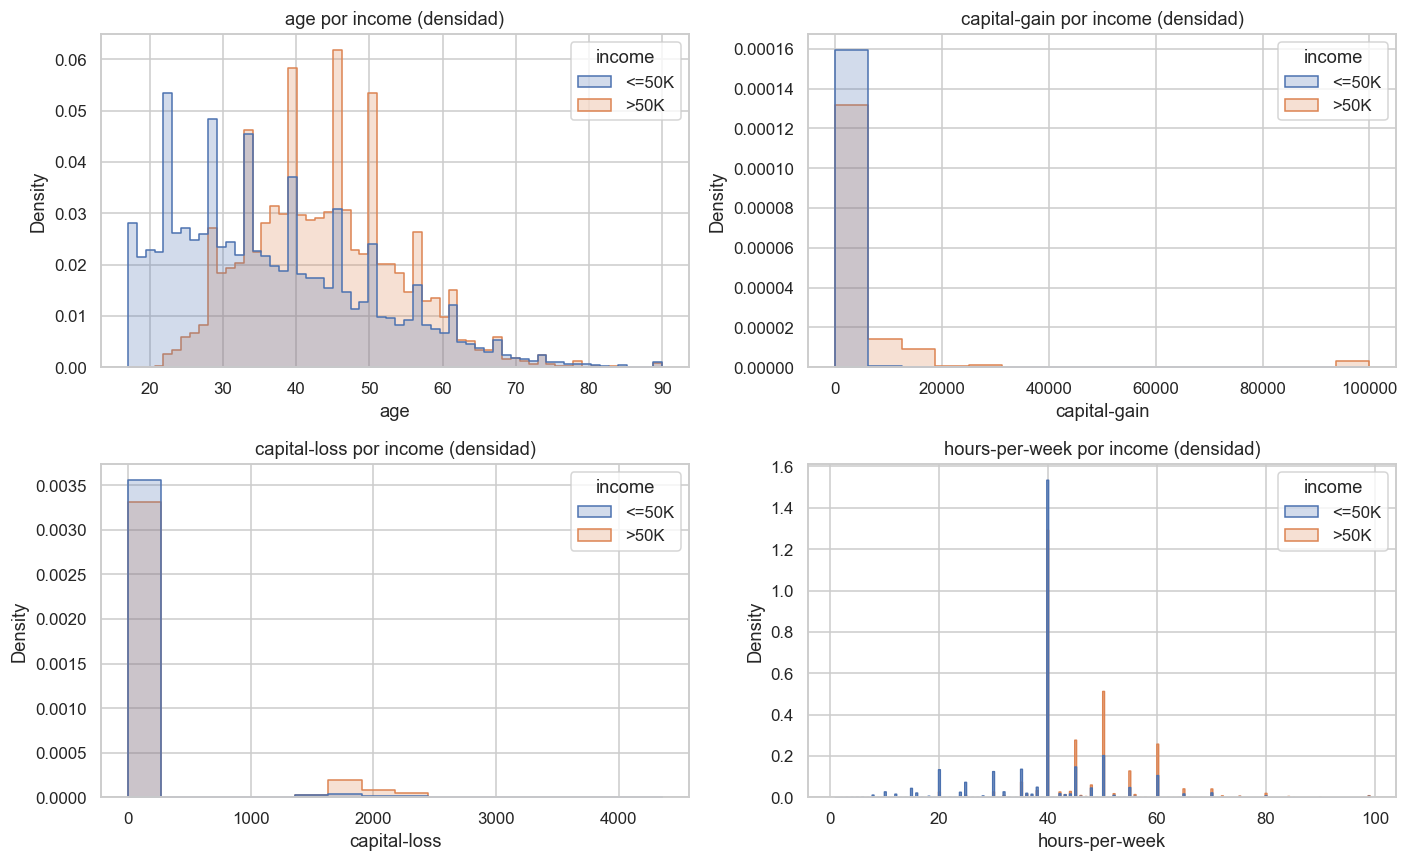

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=train, x=col, hue="income", stat="density",
                 common_norm=False, element="step", ax=ax)
    ax.set_title(f"{col} por income (densidad)")
plt.tight_layout()
plt.show()

Observaciones:

- La gente con >50K tiende a tener mayor edad y a trabajar más horas.
- En capital-gain casi todos los valores altos pertenecen a la clase >50K.

### Categóricas de baja cardinalidad (menos de 10 categorías únicas)

Miro frecuencias de cada categoría

In [19]:
cat_baja = ["sex", "race", "relationship", "workclass", "marital-status"]
for c in cat_baja:
    print(f"{c}: {train[c].nunique()} categorias unicas")

sex: 2 categorias unicas
race: 5 categorias unicas
relationship: 6 categorias unicas
workclass: 7 categorias unicas
marital-status: 7 categorias unicas


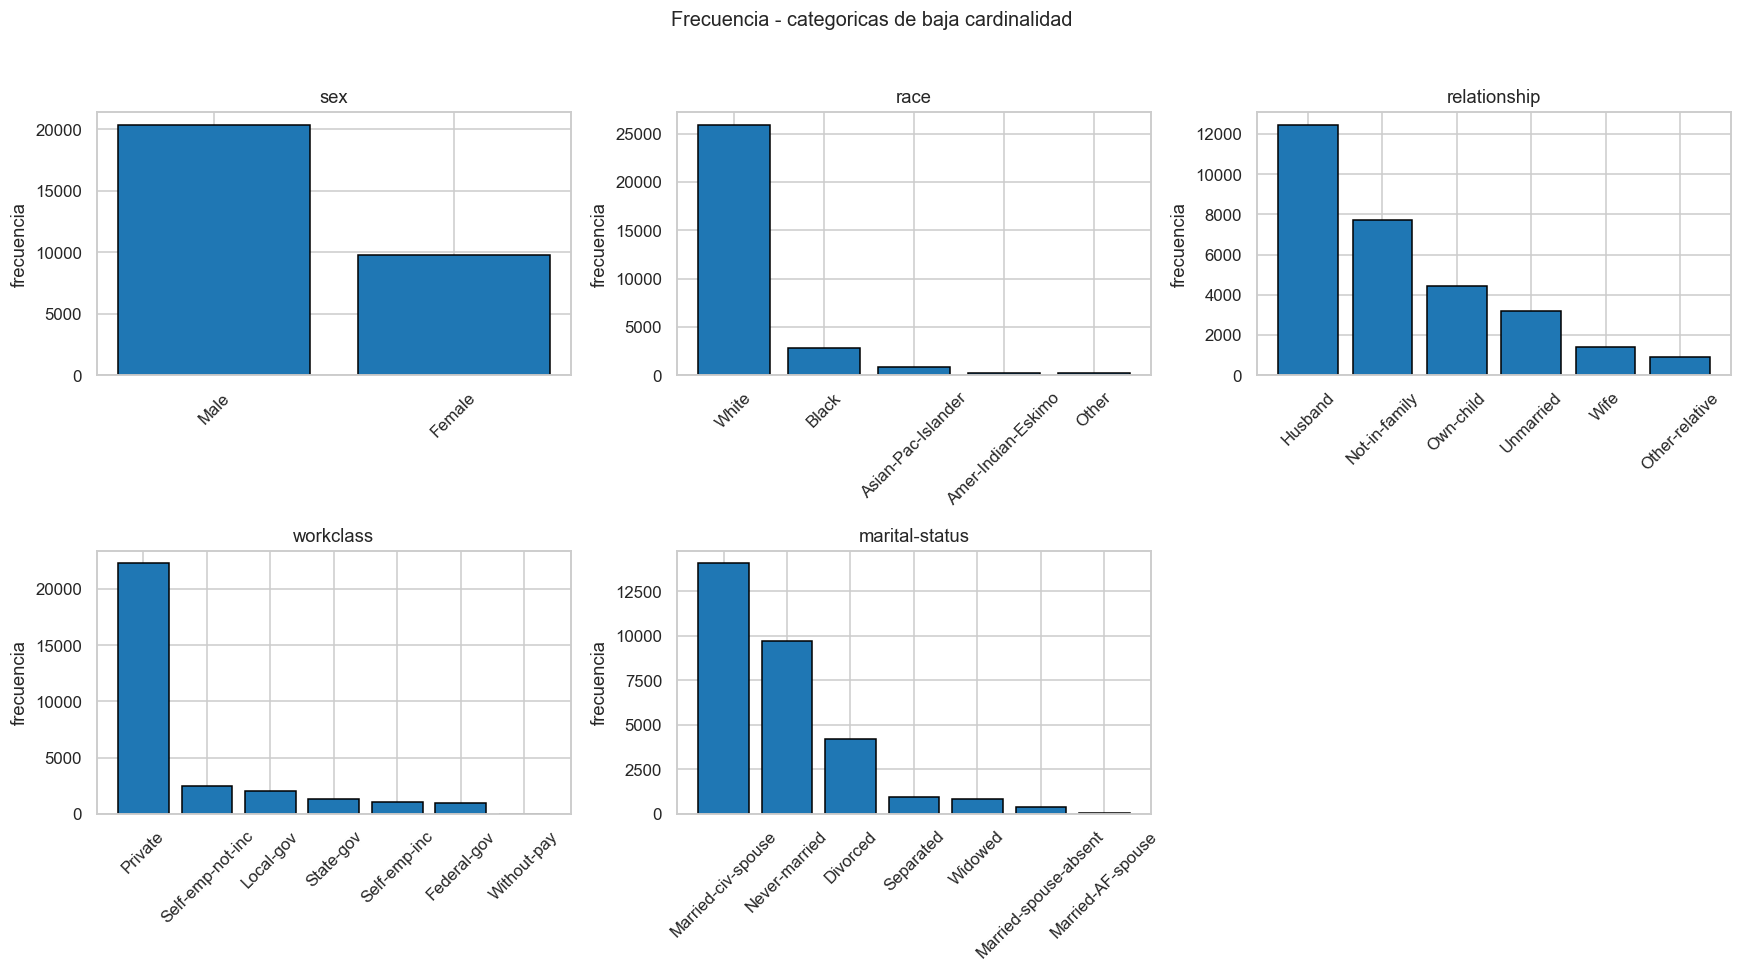

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_baja):
    vc = train[col].value_counts()
    ax.bar(vc.index, vc.values, color="tab:blue", edgecolor="black")
    ax.set_title(col); ax.set_ylabel("frecuencia")
    ax.tick_params(axis="x", rotation=45)
for ax in axes.flat[len(cat_baja):]:
    ax.axis("off")
fig.suptitle("Frecuencia - categoricas de baja cardinalidad", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Observaciones:

- sex: hay más hombres que mujeres.
- race: muy dominada por White.
- relationship: la más frecuente es Husband, seguida de Not-in-family y Own-child.
- workclass: la gran mayoría es Private.
- marital-status: se reparte sobre todo entre Married-civ-spouse y Never-married.

### Categóricas de alta cardinalidad (10 o más categorías únicas)

Miro frecuencias de cada categoría

In [21]:
cat_alta = ["occupation", "education", "native-country", "skill-profile"]
for c in cat_alta:
    print(f"{c}: {train[c].nunique()} categorias unicas")

occupation: 14 categorias unicas
education: 16 categorias unicas
native-country: 41 categorias unicas
skill-profile: 80 categorias unicas


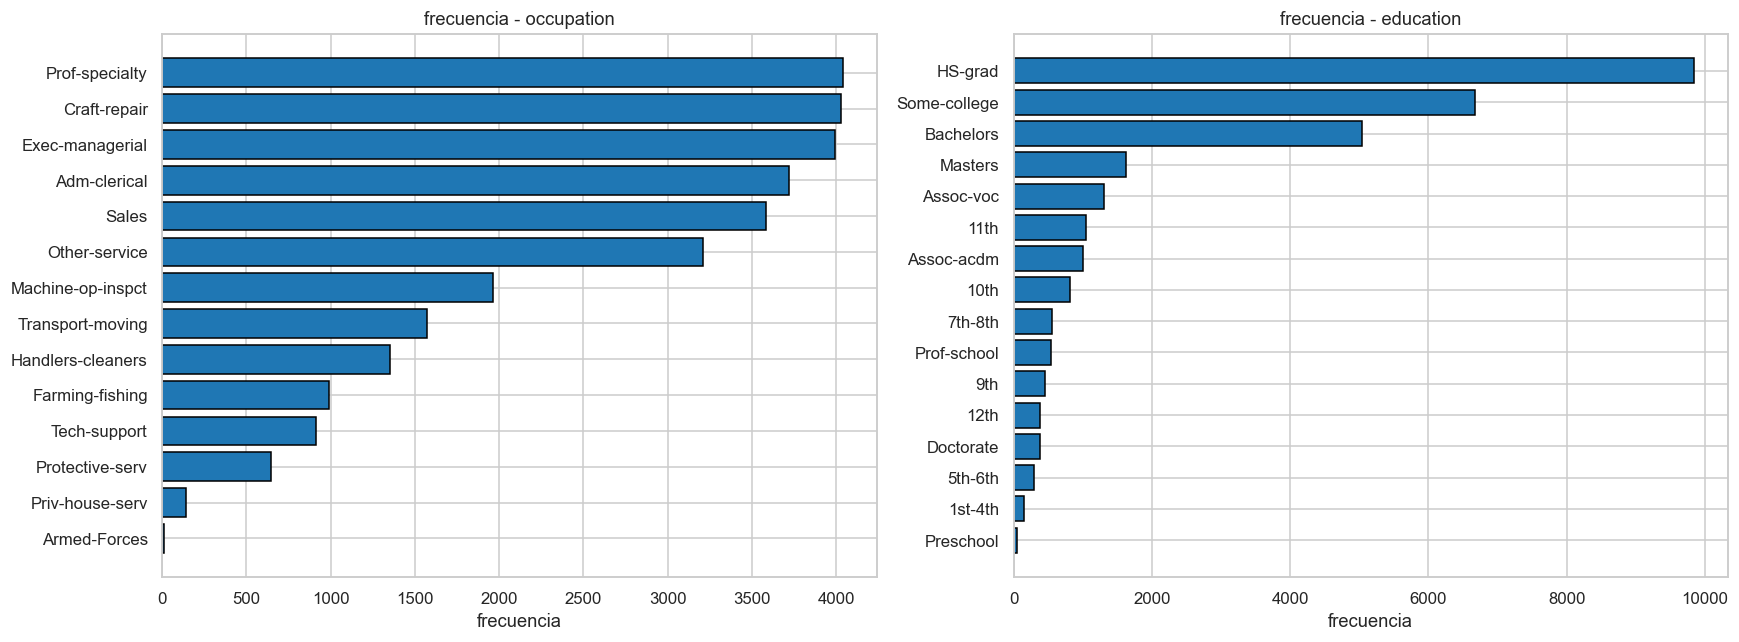

In [ ]:
# occupation (14) y education (16): muestro todas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ["occupation", "education"]):
    vc = train[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color="tab:blue", edgecolor="black")
    ax.set_title(f"frecuencia - {col}")
    ax.set_xlabel("frecuencia")
plt.tight_layout()
plt.show()

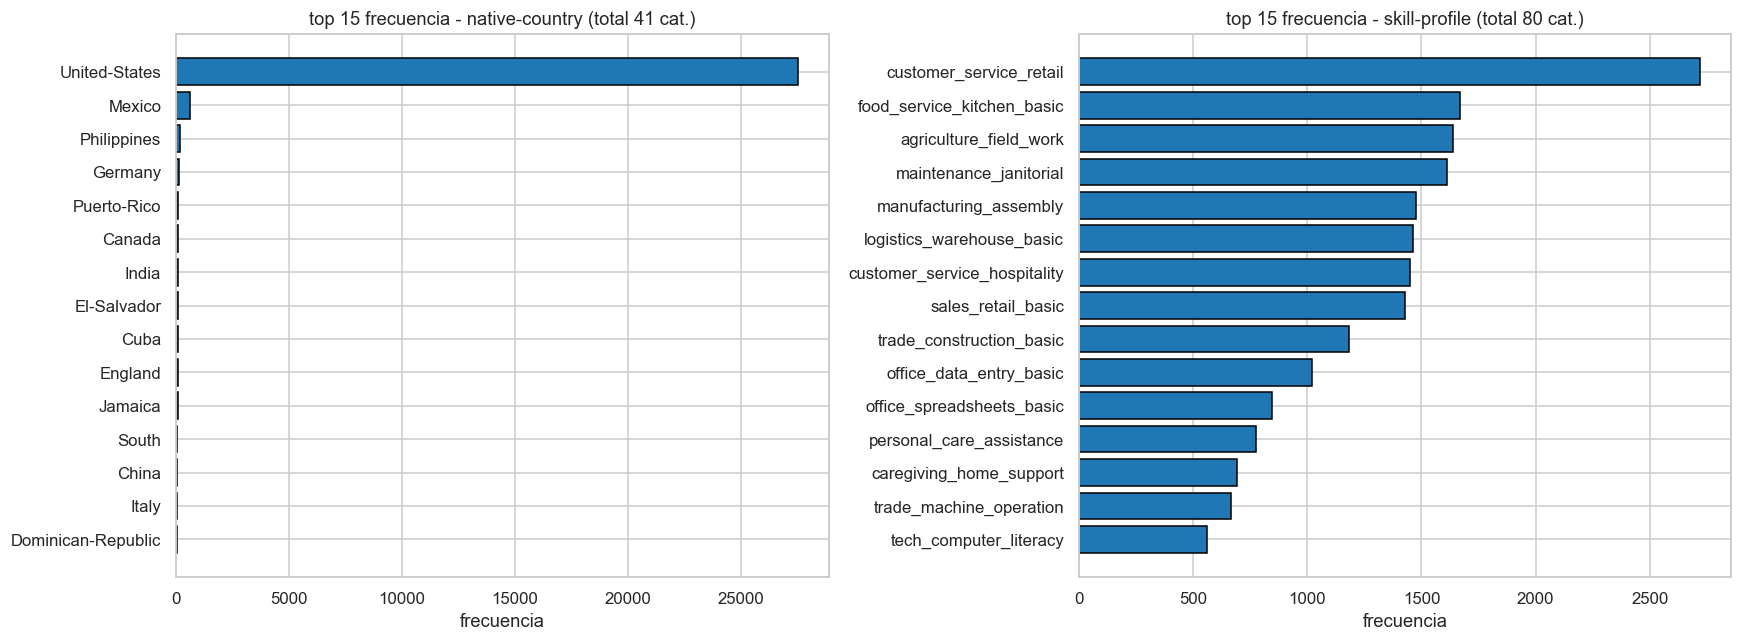

In [23]:
# native-country (41) y skill-profile (80): top 15 por frecuencia
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ["native-country", "skill-profile"]):
    vc = train[col].value_counts()
    top = vc.head(15)
    ax.barh(top.index[::-1], top.values[::-1], color="tab:blue", edgecolor="black")
    ax.set_title(f"top 15 frecuencia - {col} (total {train[col].nunique()} cat.)")
    ax.set_xlabel("frecuencia")
plt.tight_layout()
plt.show()

Observaciones:

- occupation: frecuencias repartidas, sin una categoría que domine.
- education: varias categorías con mayor frecuencia (HS-grad, Some-college, Bachelors) y otras muy chicas (Preschool, 1st-4th).
- native-country: fuertemente dominada por United-States.
- skill-profile: la frecuencia se reparte entre muchas categorías, ninguna domina de forma extrema.

### Decisión final

Con lo visto del EDA defino la transformación de cada variable:

- Numéricas (age, capital-gain, capital-loss, hours-per-week): estandarización (media 0, desvío 1).

- Categóricas de baja cardinalidad (sex, race, relationship, workclass, marital-status):
    - sex: codificación binaria 0/1. Al tener solo dos valores, una única columna alcanza y one-hot sería redundante.
    - race, relationship, workclass, marital-status: one-hot. Son pocas categorías (entre 5 y 7), así que el one-hot agrega pocas columnas y no impone un orden que no existe.

- Categóricas de alta cardinalidad (occupation, education, native-country, skill-profile):
    - occupation: embedding. Tiene 14 categorías sin orden natural. El embedding aprende una representación vectorial en lugar de sumar 14 columnas one-hot.
    - education: ordinal, de menor a mayor nivel educativo (Preschool < 1st-4th < ... < Masters < Doctorate). Tiene un orden interno claro que conviene aprovechar.
    - native-country: embedding. 41 categorías muy concentradas en un valor (United-States). El embedding evita las 41 columnas del one-hot y da representación a las categorías raras.
    - skill-profile: embedding. Misma lógica que las anteriores, pero con 80 categorías repartidas, donde el one-hot sería más costoso y disperso.

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.